In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("manishkc06/food-classification-burger-pizza-coke")

print("Path to dataset files:", path)


100%|██████████| 323M/323M [00:01<00:00, 200MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/manishkc06/food-classification-burger-pizza-coke/versions/1


In [ ]:
!kaggle datasets download -d manishkc06/food-classification-burger-pizza-coke

Dataset URL: https://www.kaggle.com/datasets/manishkc06/food-classification-burger-pizza-coke
License(s): unknown
100% 323M/323M [00:03<00:00, 101MB/s]



In [ ]:
!unzip food-classification-burger-pizza-coke.zip -d /content/food-classification-burger-pizza-coke

Streaming output truncated to the last 5000 lines.
  inflating: /content/food-classification-burger-pizza-coke/train/train/Image_1359.jpg  
  inflating: /content/food-classification-burger-pizza-coke/train/train/Image_136.jpg  
  inflating: /content/food-classification-burger-pizza-coke/train/train/Image_1360.jpg  
  inflating: /content/food-classification-burger-pizza-coke/train/train/Image_1361.jpg  
  inflating: /content/food-classification-burger-pizza-coke/train/train/Image_1362.jpg  
  inflating: /content/food-classification-burger-pizza-coke/train/train/Image_1363.jpg  
  inflating: /content/food-classification-burger-pizza-coke/train/train/Image_1364.jpg  
  inflating: /content/food-classification-burger-pizza-coke/train/train/Image_1365.jpg  
  inflating: /content/food-classification-burger-pizza-coke/train/train/Image_1366.jpg  
  inflating: /content/food-classification-burger-pizza-coke/train/train/Image_1367.jpg  
  inflating: /content/food-classification-burger-pizza-coke/

In [ ]:
import os
import pandas as pd
import shutil

# Load your CSV
# Example CSV structure:
# filename,class
# img1.jpg,dog
# img2.jpg,cat
df = pd.read_csv("/content/food-classification-burger-pizza-coke/Training_set_food.csv")

# Paths
image_folder = "/content/food-classification-burger-pizza-coke/train/train"        # folder with all images
output_folder = "/content/sorted_data"  # new folder to store class-wise images

# Create class folders and copy images
for _, row in df.iterrows():
    file_name = row['filename']
    class_name = row['label']

    # Create class folder if it doesn't exist
    class_folder = os.path.join(output_folder, class_name)
    os.makedirs(class_folder, exist_ok=True)

    # Source and destination paths
    src_path = os.path.join(image_folder, file_name)
    dst_path = os.path.join(class_folder, file_name)

    # Copy image if it exists
    if os.path.exists(src_path):
        shutil.copy(src_path, dst_path)   # use shutil.move if you want to move instead of copy


In [ ]:
import os

# Path to your sorted dataset
base_folder = "/content/sorted_data"

# Loop through each class folder
for class_name in os.listdir(base_folder):
    class_folder = os.path.join(base_folder, class_name)

    if os.path.isdir(class_folder):
        num_images = len(os.listdir(class_folder))
        print(f"Class '{class_name}' has {num_images} images")


Class 'Pizza' has 1800 images
Class 'Softdrinks' has 1800 images
Class 'burgers' has 1800 images


In [ ]:
from keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
img = image.load_img('/content/sorted_data/burgers/Image_1.jpg', target_size=(200,200))

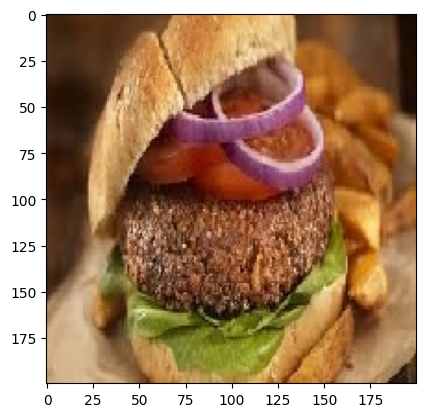

In [ ]:
plt.imshow(img)

In [ ]:
type(img)

PIL.Image.Image

In [ ]:
batch_size = 32
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen = train_datagen.flow_from_directory(
    "/content/sorted_data",
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_gen = val_datagen.flow_from_directory(
    "/content/sorted_data",
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 4320 images belonging to 3 classes.
Found 1080 images belonging to 3 classes.


In [ ]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from keras.layers import Activation
from keras.layers import BatchNormalization

In [ ]:
model = Sequential()

model.add(Conv2D(32, (3,3), input_shape=(128,128, 3), activation='relu', padding='valid'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2), padding='valid'))

model.add(Conv2D(64, (3,3), activation='relu', padding='valid'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2), padding='valid'))

model.add(Conv2D(128, (3,3), activation='relu', padding='valid'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2), padding='valid'))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(3, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_30 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_32 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,313,987 (12.64 MB)

 Trainable params: 3,313,539 (12.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [ ]:
class_weight = {0: 2, 1: 1.0, 2: 2.0}

history = model.fit(
    train_gen,
    steps_per_epoch=len(train_gen),
    epochs=10,
    validation_data=val_gen,
    validation_steps=len(val_gen),
    class_weight=class_weight
)

Epoch 1/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 37s 234ms/step - accuracy: 0.6935 - loss: 1.7112 - val_accuracy: 0.3343 - val_loss: 2.9992
Epoch 2/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 29s 212ms/step - accuracy: 0.7553 - loss: 1.0525 - val_accuracy: 0.5750 - val_loss: 1.2730
Epoch 3/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 29s 211ms/step - accuracy: 0.7889 - loss: 0.8896 - val_accuracy: 0.6694 - val_loss: 1.0303
Epoch 4/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 30s 219ms/step - accuracy: 0.8130 - loss: 0.8045 - val_accuracy: 0.7722 - val_loss: 0.5980
Epoch 5/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 29s 212ms/step - accuracy: 0.8303 - loss: 0.7037 - val_accuracy: 0.8333 - val_loss: 0.4471
Epoch 6/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 29s 216ms/step - accuracy: 0.8588 - loss: 0.6328 - val_accuracy: 0.8213 - val_loss: 0.4529
Epoch 7/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 32s 234ms/step - accuracy: 0.8572 - loss: 0.5791 - val_accuracy: 0.7935 - val_loss: 0.6037
Epoch 8/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 29s 213ms/step - accuracy: 0.8611 - loss: 0

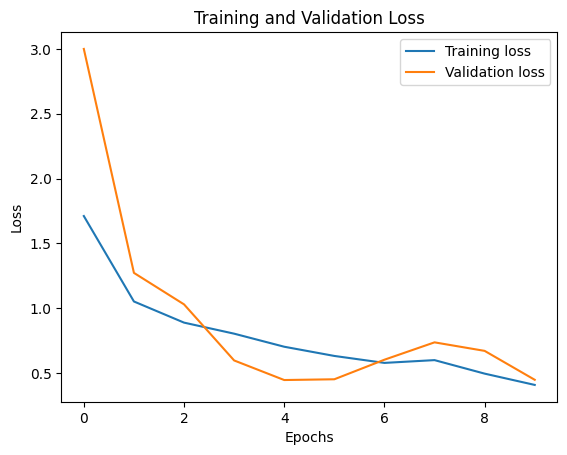

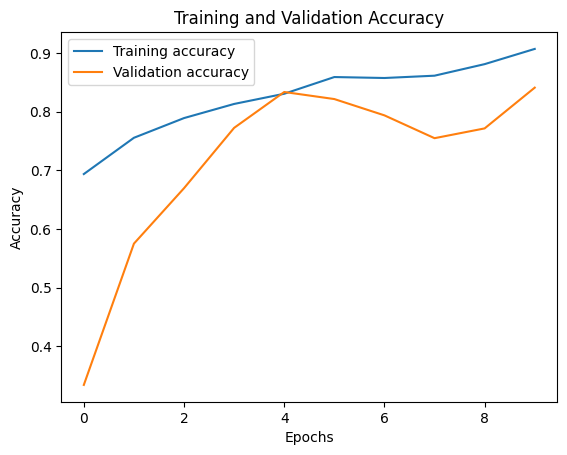

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation loss
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot training & validation accuracy
plt.plot(history.history['accuracy'], label='Training accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [ ]:
val_loss, val_acc = model.evaluate(val_gen)
print("Validation accuracy:", val_acc)
print("Validation loss:", val_loss)


34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - accuracy: 0.8407 - loss: 0.4489
Validation accuracy: 0.8407407402992249
Validation loss: 0.44889572262763977


In [ ]:
model.save("my_model.keras")   # saves entire model


In [ ]:
from tensorflow.keras.models import load_model
model = load_model("my_model.keras")

In [ ]:
print(train_gen.class_indices)

{'Pizza': 0, 'Softdrinks': 1, 'burgers': 2}


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 614ms/step
Predicted class: [0]


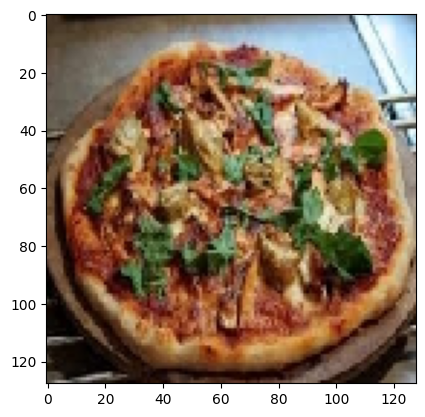

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

img = image.load_img("/content/sorted_data/Pizza/Image_1801.jpg", target_size=(128,128))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)
plt.imshow(img)
prediction = model.predict(img_array)
predicted_class = np.argmax(prediction, axis=1)
print("Predicted class:", predicted_class)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Predicted class: [1]


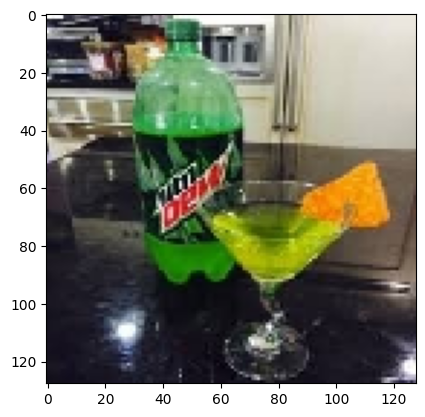

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

img = image.load_img("/content/sorted_data/Softdrinks/Image_3601.jpg", target_size=(128,128))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)
plt.imshow(img)
prediction = model.predict(img_array)
predicted_class = np.argmax(prediction, axis=1)
print("Predicted class:", predicted_class)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Predicted class: [1]


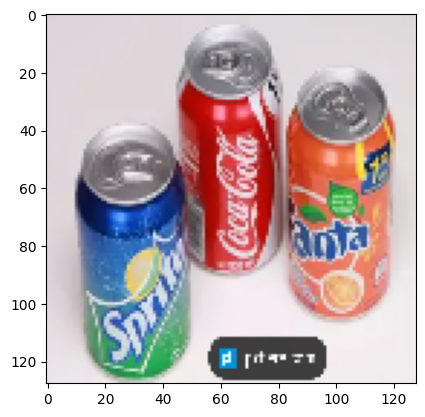

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

img = image.load_img("/content/Screenshot 2026-06-24 150628.png", target_size=(128,128))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)
plt.imshow(img)
prediction = model.predict(img_array)
predicted_class = np.argmax(prediction, axis=1)
print("Predicted class:", predicted_class)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Predicted class: [2]


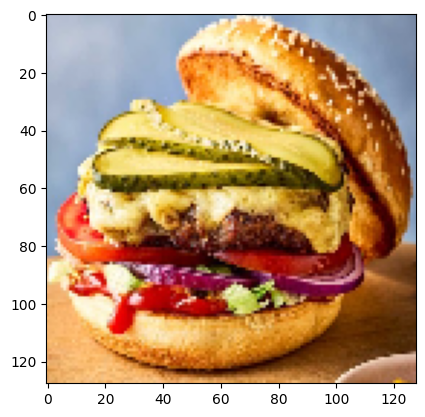

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

img = image.load_img("/content/Screenshot 2026-06-24 150808.png", target_size=(128,128))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)
plt.imshow(img)
prediction = model.predict(img_array)
predicted_class = np.argmax(prediction, axis=1)
print("Predicted class:", predicted_class)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Predicted class: [0]


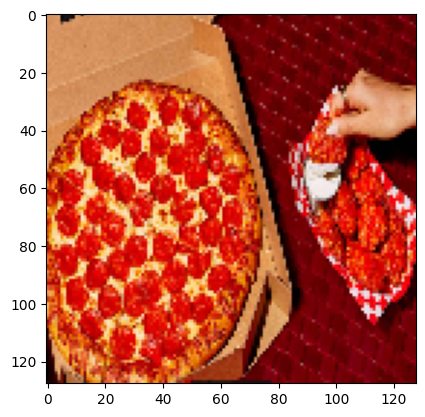

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

img = image.load_img("/content/Screenshot 2026-06-24 154928.png", target_size=(128,128))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)
plt.imshow(img)
prediction = model.predict(img_array)
predicted_class = np.argmax(prediction, axis=1)
print("Predicted class:", predicted_class)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Predicted class: [0]


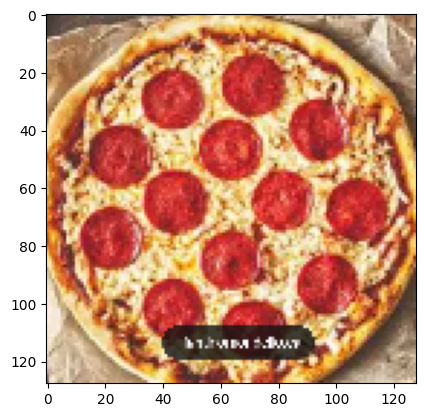

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

img = image.load_img("/content/Screenshot 2026-06-24 204925.png", target_size=(128,128))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)
plt.imshow(img)
prediction = model.predict(img_array)
predicted_class = np.argmax(prediction, axis=1)
print("Predicted class:", predicted_class)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Predicted class: [0]


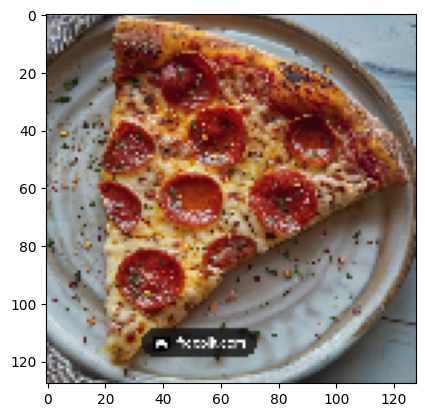

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

img = image.load_img("/content/Screenshot 2026-06-24 204956.png", target_size=(128,128))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)
plt.imshow(img)
prediction = model.predict(img_array)
predicted_class = np.argmax(prediction, axis=1)
print("Predicted class:", predicted_class)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Predicted class: [2]


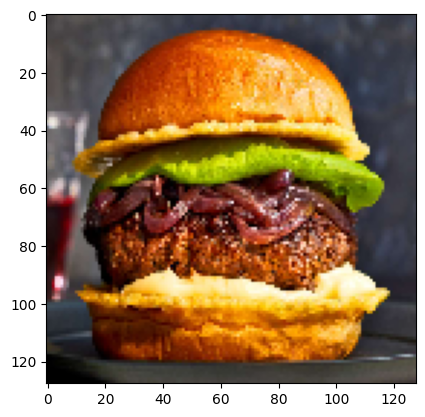

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

img = image.load_img("/content/Screenshot 2026-06-24 211549.png", target_size=(128,128))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)
plt.imshow(img)
prediction = model.predict(img_array)
predicted_class = np.argmax(prediction, axis=1)
print("Predicted class:", predicted_class)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Predicted class: [2]


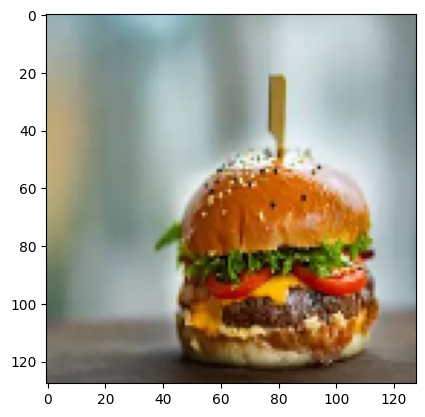

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

img = image.load_img("/content/Screenshot 2026-06-24 211629.png", target_size=(128,128))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)
plt.imshow(img)
prediction = model.predict(img_array)
predicted_class = np.argmax(prediction, axis=1)
print("Predicted class:", predicted_class)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Predicted class: [2]


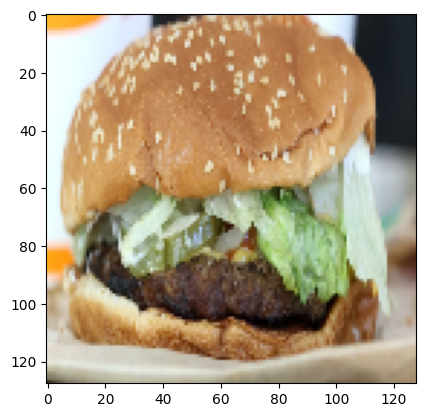

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

img = image.load_img("/content/Screenshot 2026-06-24 211725.png", target_size=(128,128))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)
plt.imshow(img)
prediction = model.predict(img_array)
predicted_class = np.argmax(prediction, axis=1)
print("Predicted class:", predicted_class)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Predicted class: [1]


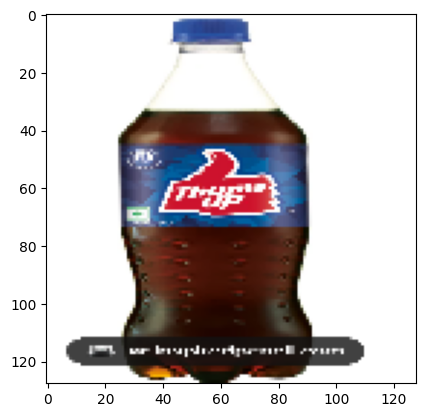

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

img = image.load_img("/content/Screenshot 2026-06-24 201304.png", target_size=(128,128))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)
plt.imshow(img)
prediction = model.predict(img_array)
predicted_class = np.argmax(prediction, axis=1)
print("Predicted class:", predicted_class)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Predicted class: [0]


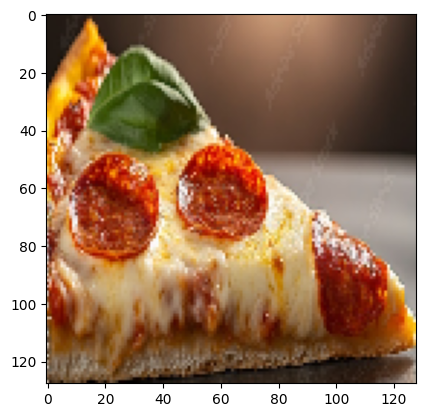

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

img = image.load_img("/content/Screenshot 2026-06-24 221453.png", target_size=(128,128))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)
plt.imshow(img)
prediction = model.predict(img_array)
predicted_class = np.argmax(prediction, axis=1)
print("Predicted class:", predicted_class)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Predicted class: [2]


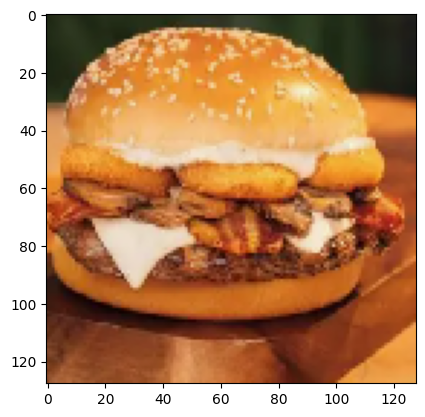

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

img = image.load_img("/content/Screenshot 2026-06-24 221828.png", target_size=(128,128))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)
plt.imshow(img)
prediction = model.predict(img_array)
predicted_class = np.argmax(prediction, axis=1)
print("Predicted class:", predicted_class)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Predicted class: [2]


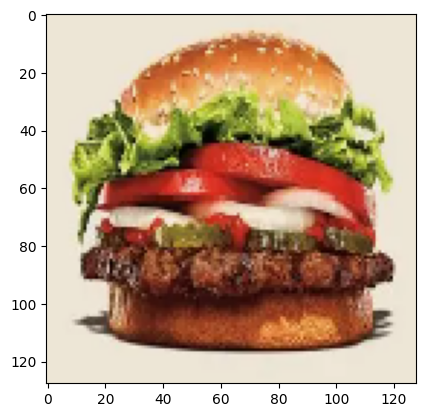

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

img = image.load_img("/content/Screenshot 2026-06-24 221949.png", target_size=(128,128))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)
plt.imshow(img)
prediction = model.predict(img_array)
predicted_class = np.argmax(prediction, axis=1)
print("Predicted class:", predicted_class)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Predicted class: [2]


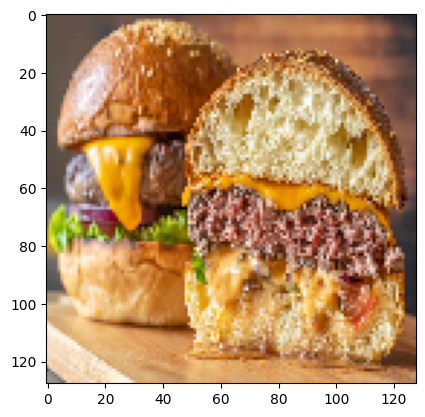

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

img = image.load_img("/content/Screenshot 2026-06-24 221844.png", target_size=(128,128))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)
plt.imshow(img)
prediction = model.predict(img_array)
predicted_class = np.argmax(prediction, axis=1)
print("Predicted class:", predicted_class)
